This notebook loads a previously trained Convolutional Neural Network (CNN) <br>
model and uses it to classify new medical images as either benign (non-cancerous) <br>
or malignant (cancerous). <br>

It performs the following steps: <br>
1. Loads the trained model from the computer's disk. <br>
2. Preprocesses the input images to match the training format. <br>
3. Runs predictions on new images. <br>
4. Interprets and displays the results.

<h3>Import Libraries</h3>

In [1]:
# Core libraries

# os handles file paths.
import os

# numpy performs numerical operations.
import numpy as np

# Visualisation

# matplotlib displays images.
import matplotlib.pyplot as plt

# Tensorflow / Keras

# load_model() loads the trained .h5 model.
from tensorflow.keras.models import load_model

# image has utilities for loading and processing images.
from tensorflow.keras.preprocessing import image

I0000 00:00:1777172226.572265   45302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777172226.903494   45302 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777172231.782943   45302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<h3>Define the Paths</h3>

In [2]:
# The path to the trained model.

# Variable names that are written in all uppercase letters tell
# whoever is reading the program, that the variable is a constant.

# .h5 files are not meant to be human-readable. It's a binary file
# in the HDF5 format.

# ./ indicates that the program will search for the file in the current
# directory.

# ../ means go one directory level above.
MODEL_PATH = './../outputs/cancer_model.h5'

# The path to the test image.
TEST_IMAGE_PATH = './../test_images/test_image.jpg'

<h3>Load the Model</h3>

In [3]:
# Load the trained model.
model = load_model(MODEL_PATH)

# Print the model summary.
model.summary()

E0000 00:00:1777172848.845615   45302 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,205 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

<h3>Image Preprocessing Function</h3>

In [10]:
def preprocess_image(img_path, target_size=(150, 150)):
    # Load and preprocess an image for prediction.

    # Load the image and resize.
    img = image.load_img(img_path, target_size=target_size)

    # Convert the image to an array.
    img_array = image.img_to_array(img)

    # Expand the dimensions to match model input.
    img_array = np.expand_dims(img_array, axis=0)

    # Normalise the pixel values.
    img_array = img_array / 255.0

    # When a user-defined function in Python returns multiple variables,
    # the variables are returns in a tuple.
    return img, img_array

In [11]:
# def get_items():
#     return "1", "2"

# items = get_items()

# print("type(items):", type(items))

<h3>Prediction Formula</h3>

In [12]:
def predict_image(model, img_array):
    # Predict whether the image is benign or malignant.
    prediction = model.predict(img_array)

    # Obtain the probability.
    probability = prediction[0][0]

    # Classification decision where 0.5 is the threshold.
    if probability > 0.5:
        label = "Malignant (Cancerous)"
    else:
        label = "Benign (Non-Cancerous)"

    return label, probability

<h3>Run the Prediction On a Single Image</h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


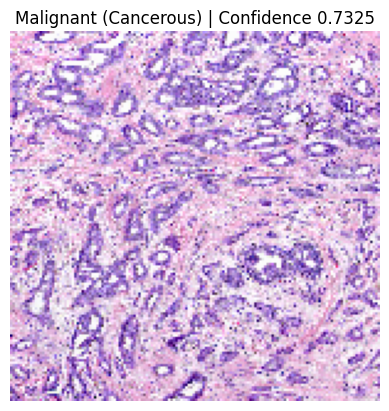

In [13]:
# Preprocess the image.
img, img_array = preprocess_image(TEST_IMAGE_PATH)

# Make a prediction.
label, probability = predict_image(model, img_array)

# Display the image.
plt.imshow(img)
plt.axis('off')
plt.title(f"{label} | Confidence {probability:.4f}")
plt.show()